In [1]:
using Pkg
Pkg.activate(normpath(@__DIR__,  ".."))

  Activating project at `~/DART`


In [2]:
include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")))
using PyPlot, JLD2

#### load data

In [3]:
# Reusable base folder
data_dir = "../synthetic_data/ideal_data_res"

"""
    load_group(dir, on_file, off_file, acc_file)

Load three JLD2 files for a group:
- `on_file`  -> extract ON means (index 1)
- `off_file` -> extract OFF means (index 2)
- `acc_file` -> extract accuracies and keep records

Returns a named tuple: (onx, ony, offx, offy, acc, records)
"""
function load_group(dir, on_file, off_file, acc_file)
    # ON
    @load joinpath(dir, on_file) rn_met_dl
    onx = [m.truet_mean[1] for m in rn_met_dl]
    ony = [m.binart_mean[1] for m in rn_met_dl]

    # OFF
    @load joinpath(dir, off_file) rn_met_dl
    offx = [m.truet_mean[2] for m in rn_met_dl]
    offy = [m.binart_mean[2] for m in rn_met_dl]

    # ACC + keep records
    @load joinpath(dir, acc_file) rn_met_dl
    acc     = [m.acc for m in rn_met_dl]
    records = copy(rn_met_dl)

    return (onx=onx, ony=ony, offx=offx, offy=offy, acc=acc, records=records)
end

b   = load_group(data_dir,
        "mtel_dlb33_compare_seed_1.jld2", 
        "mtel_dlb33_compare_seed_1.jld2",
        "mtel_dlb33_compare_seed_1.jld2")

nb1 = load_group(data_dir,
        "mtel_dlnb133_compare_seed_1.jld2",
        "mtel_dlnb133_compare_seed_1.jld2",
        "mtel_dlnb133_compare_seed_1.jld2")

nb0 = load_group(data_dir,
        "mtel_dlnb033_compare_seed_1.jld2",
        "mtel_dlnb033_compare_seed_1.jld2",
        "mtel_dlnb033_compare_seed_1.jld2")

# ---- Concatenate results ----
onx_scatter  = vcat(b.onx,  nb1.onx,  nb0.onx)
ony_scatter  = vcat(b.ony,  nb1.ony,  nb0.ony)
offx_scatter = vcat(b.offx, nb1.offx, nb0.offx)
offy_scatter = vcat(b.offy, nb1.offy, nb0.offy)
rn_acc_dl    = vcat(b.acc,  nb1.acc,  nb0.acc)

# If you also want a combined rn_met_dl:
rn_met_dl = vcat(b.records, nb1.records, nb0.records);

# Base folder
data_dir = "../synthetic_data/base_compare"

"""
    load_compare(path)

Load one compare-method file from JLD2.
Returns a tuple (filter, met).
"""
function load_compare(path::String)
    data = JLD2.load(path)
    return data["rn_binar_filter"], data["rn_met_binar"]
end

# ---- Load all groups ----
hmmb_filter,  hmmb_met  = load_compare(joinpath(data_dir, "telb_hmm.jld2"))
hmmnb1_filter, hmmnb1_met = load_compare(joinpath(data_dir, "telnb1_hmm.jld2"))
hmmnb0_filter, hmmnb0_met = load_compare(joinpath(data_dir, "telnb0_hmm.jld2"))

# ---- Concatenate results ----
rn_hmm_filter = vcat(hmmb_filter, hmmnb1_filter, hmmnb0_filter)
rn_met_hmm = vcat(hmmb_met, hmmnb1_met, hmmnb0_met);

#### plot

In [4]:
using Statistics, StatsBase
Line2D = PyPlot.matplotlib.lines.Line2D;

In [5]:
fs1 = 11.5; fs2 = 10.5; fs3 = 10;
const SPINE_KEYS = ("left", "right", "top", "bottom")

"""Set common axis style: spine widths and tick params. Pass logscale=true for scatter axes."""
function style_ax!(ax; wd=1.2, logscale=false)
    logscale && (ax.set_xscale("log"); ax.set_yscale("log"))
    ax.tick_params(axis="both", labelsize=fs2, width=wd)
    for k in SPINE_KEYS; ax.spines[k].set_linewidth(wd); end
end

"""
    plot_bar!(ax, acc, idl, ids, thresh)

Normalised histogram pair: Λ > thresh filled, Λ ≤ thresh outlined.
Returns ncounts for the filled group (used to set y-ticks).
"""
function plot_bar!(ax, acc, idl, ids, thresh)
    function norm_hist(idx)
        counts, bins, _ = plt.hist(acc[idx], bins=FD_bins(acc[idx]), alpha=0)
        counts ./ sum(counts), bins
    end

    nc_l, bins_l = norm_hist(idl)
    ax.bar(bins_l[1:end-1], nc_l, width=diff(bins_l),
           color="#abd9e9", edgecolor="white", lw=0.3, alpha=0.8,
           label=L"\Lambda > " * string(thresh))

    nc_s, bins_s = norm_hist(ids)
    ax.bar(bins_s[1:end-1], nc_s, width=diff(bins_s),
           facecolor="none", edgecolor="#fdae61", lw=1.2,
           label=L"\Lambda \leq " * string(thresh))

    return nc_l   # for y-tick range
end

"""
    plot_scatter!(ax, x, y, rn_met, thresh; second_leg=false)

Scatter of predicted vs true dwell times, split by Λ threshold.
"""
function plot_scatter!(ax, x, y, rn_met, thresh; second_leg=false)
    ratio = [m.p[end-1] / m.truet_mean[2] for m in rn_met]
    idl   = findall(>(thresh), ratio)
    ids   = findall(<=(thresh), ratio)
    acc   = [m.acc for m in rn_met]

    ax.scatter(x[idl], y[idl], s=10, c="#abd9e9",
        label=L"\langle \alpha \rangle_{\Lambda > 0.5} = " * string(round(mean(acc[idl]), digits=3)))
    ax.scatter(x[ids], y[ids], s=10, facecolors="none", edgecolors="#fdae61", linewidths=1.0,
        label=L"\langle \alpha \rangle_{\Lambda \leq 0.5} = " * string(round(mean(acc[ids]), digits=3)))

    xy_min, xy_max = minimum(vcat(x, y)) * 0.9, maximum(vcat(x, y)) * 1.1
    ax.plot(xy_min:0.1:xy_max, xy_min:0.1:xy_max, c="#2c7bb6", linestyle="--", linewidth=1.5)

    style_ax!(ax; logscale=true)
    leg1 = ax.legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="lower right")
    ax.add_artist(leg1)

    if second_leg
        handles = [
            Line2D([], [], marker="o", color="w", markerfacecolor="#abd9e9",
                   markersize=6, label=L"\Lambda > " * string(thresh)),
            Line2D([], [], marker="o", color="w", markeredgecolor="#fdae61",
                   markerfacecolor="none", markersize=6, label=L"\Lambda \leq " * string(thresh))
        ]
        ax.legend(handles=handles, loc="upper left", fontsize=fs3)
    end
end

"""
    fill_row!(axs_row, rn_met, thresh)

Fill one grid row (acc histogram, ON scatter, OFF scatter) for a given method.
"""
function fill_row!(axs_row, rn_met, thresh)
    ratio = [m.p[end-1] / m.truet_mean[2] for m in rn_met]
    idl   = findall(>(thresh), ratio)
    ids   = findall(<=(thresh), ratio)
    acc   = [m.acc for m in rn_met]

    ncounts = plot_bar!(axs_row[1], acc, idl, ids, thresh)
    axs_row[1].set_ylabel("Probability", fontsize=fs1)
    axs_row[1].legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="upper left")
    axs_row[1].set_yticks(0:0.05:maximum(ncounts))
    axs_row[1].set_xlim(minimum(acc) - 0.1, 1.0)
    style_ax!(axs_row[1])

    plot_scatter!(axs_row[2], [m.truet_mean[1] for m in rn_met], [m.binart_mean[1] for m in rn_met], rn_met, thresh)
    axs_row[2].set_ylabel("Mean on-time", fontsize=fs1)

    plot_scatter!(axs_row[3], [m.truet_mean[2] for m in rn_met], [m.binart_mean[2] for m in rn_met], rn_met, thresh)
    axs_row[3].set_ylabel("Mean off-time", fontsize=fs1)
end

function plot_comparison(onx, ony, offx, offy, rn_acc_dl, rn_mets, titles, thresh)
    fig, axs = plt.subplots(2, 3, figsize=(11, 5))

    # Row 1: comparison methods (HMM, etc.)
    for (i, rn_met) in enumerate(rn_mets)
        fill_row!(axs[i, :], rn_met, thresh)
    end

    # Row 2: DART (DL model) — uses pooled rn_acc_dl and rn_met_dl
    ratio = [m.p[end-1] / m.truet_mean[2] for m in rn_mets[1]]
    idl   = findall(>(thresh), ratio)
    ids   = findall(<=(thresh), ratio)

    ncounts = plot_bar!(axs[2, 1], rn_acc_dl, idl, ids, thresh)
    axs[2, 1].set_ylabel("Probability", fontsize=fs1)
    axs[2, 1].legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="upper left")
    axs[2, 1].set_yticks(0:0.05:maximum(ncounts))
    axs[2, 1].set_xlim(minimum(m.acc for m in vcat(rn_mets...)) - 0.1, 1.0)
    axs[2, 1].set_xlabel(L"\mathrm{Accuracy}~\alpha", fontsize=fs1)
    style_ax!(axs[2, 1])

    plot_scatter!(axs[2, 2], onx, ony, rn_met_dl, thresh)
    axs[2, 2].set_ylabel("Mean on-time", fontsize=fs1)
    axs[2, 2].set_xlabel("True mean on-time", fontsize=fs1)

    plot_scatter!(axs[2, 3], offx, offy, rn_met_dl, thresh)
    axs[2, 3].set_ylabel("Mean off-time", fontsize=fs1)
    axs[2, 3].set_xlabel("True mean off-time", fontsize=fs1)
    axs[2, 3].set_ylim([0.02, 11])

    fig.tight_layout()
    return fig
end;

rn_mets = [rn_met_hmm]
titles  = ["HMM"];


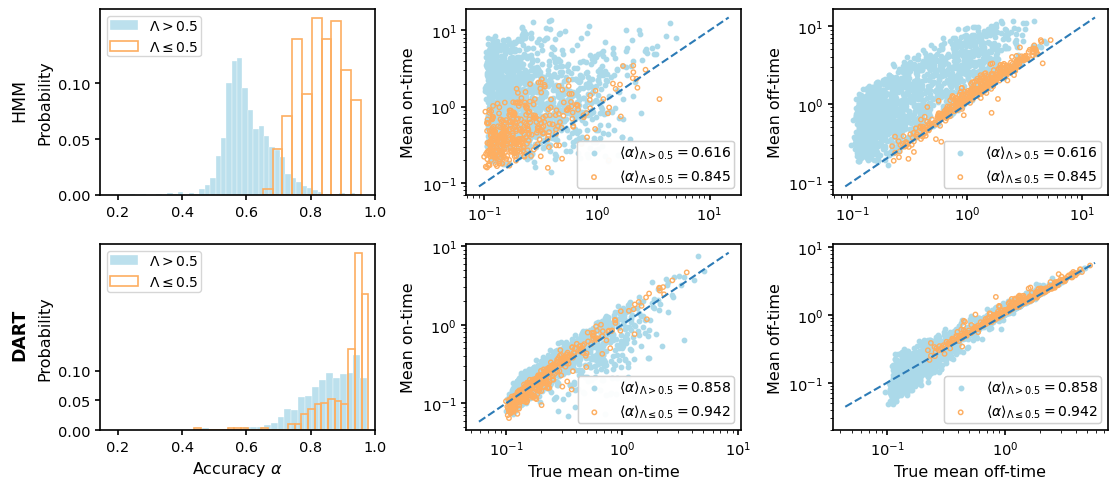

In [6]:
fig = plot_comparison(onx_scatter, ony_scatter, offx_scatter, offy_scatter, rn_acc_dl, rn_mets, titles, 0.5);

row_labels = ["HMM", "DART"]
yposs      = [0.79, 0.32]
for (label, ypos) in zip(row_labels, yposs)
    fw = label == "DART" ? "semibold" : "normal"
    fig.text(0.005, ypos, label; fontsize=12.5, va="center", ha="right", rotation=90, fontweight=fw)
end

#mkdir("figs")
fig.savefig("figs/compare_tel.pdf", bbox_inches="tight", dpi=800)


#### R^2 calculations

In [9]:
hmm_trues = [m.truet_mean for m in rn_met_hmm]
hmm_vals = [m.binart_mean for m in rn_met_hmm];

In [10]:
fit_line(map(x->x[1],hmm_trues),map(x->x[1],hmm_vals)),fit_line(map(x->x[2],hmm_trues),map(x->x[2],hmm_vals))

((0.9469800476080154, 1.3727262496140662, 0.04567554724155065), (1.4975489083428746, 0.8356480384026332, 0.36684990471151513))

In [11]:
fit_line(onx_scatter,ony_scatter),fit_line(offx_scatter,offy_scatter)

((1.0064753558351909, 0.007736728139029703, 0.781658939492373), (1.0616646957590812, 0.018965353727686263, 0.9803723436950386))